# Example 8: Distributed ISL ODTS with a Rotating Lunar Surface Station

This tutorial studies **distributed** onboard orbit determination and time synchronization (ODTS) for a lunar relay constellation. The simulated constellation is NASA's five-satellite LCRNS Reference Constellation 3.1 in Elliptical Lunar Frozen Orbits (ELFOs).

Unlike a single-hub design, **every satellite runs its own Schmidt EKF in parallel** (five filters). Each filter estimates its own 8-state `[position, velocity, clock bias, clock drift]` and carries the other four satellites as *consider* states — propagated and used in the measurement update, but never directly corrected.

Two measurement types feed the filters:

- **Two-way crosslink range/range-rate** between every pair of satellites. Coherent two-way ranging is nearly clock-bias free, so it strongly constrains *relative* geometry but says little about absolute timing.
- **A one-way pseudorange from a lunar surface station.** A ground station fixed near the south pole (known position via lunar rotation, known/disciplined clock) serves the satellites **one at a time in a round-robin rotation**, gated by an elevation mask. Because the station's inertial position is known and its pseudorange `ρ = |r_sat − r_station| + c·b_sat` carries the satellite clock bias directly, it supplies the absolute timing reference the crosslinks lack.

The five filters are also **coupled**: every 10 minutes each satellite broadcasts its posterior self-estimate (mean **and** covariance), and every other filter overwrites the matching consider block with it. A neighbor's own filter — aided by crosslinks and the rotating station — is a better source of that neighbor's state than a static broadcast ephemeris, so this exchange progressively tightens everyone's consider states.

This replaces the fragile Earth-GPS aiding of the earlier version of this example: seen from the Moon the GPS constellation subtends only ~4°, leaving the Earth-radial position nearly degenerate with the clock. A lunar-local station has well-conditioned geometry and needs no artificial noise inflation.

The estimators live in `lupnt::IslOdtsApp`; `lupnt::IslOdtsSimulation` generates the truth trajectories, the rotating-station schedule, and the staged measurements, and orchestrates the periodic state exchange between the parallel filters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import os, sys
from pathlib import Path

# Use THIS repo's pylupnt/data, not a stale copy on a global PYTHONPATH (~/.zshrc) or kernelspec.
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data/ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt

np.random.seed(0)

# Host heavy interactive figures on lupnt-doc-assets instead of embedding them.
import sys as _sys
from pathlib import Path as _Path

for _p in [_Path.cwd(), *_Path.cwd().parents]:
    if (_p / "python" / "examples" / "_doc_assets.py").exists():
        _sys.path.insert(0, str(_p / "python" / "examples"))
        break
from _doc_assets import embed_plotly, embed_cesium_scene

[00.01][PyLuPNT] Initializing


## 1. LCRNS Reference Constellation -- all five satellites

The LCRNS reference document provides five ELFO satellite states at the reference
epoch **2027-03-01 00:00:00.000 UTC**, in the Moon-centered ICRF (Table 2 of the
reference). `SV-1` and `SV-2` share one orbit plane (~180&deg; apart in true anomaly);
`SV-3` and `SV-4` share a second plane; `SV-5` occupies a third. We use these Cartesian
states directly (so no Keplerian-element/frame-convention assumptions are needed) as
the truth trajectories for all five satellites. The constellation is **fully
cross-linked** -- every satellite ranges to every other -- and each runs its own onboard
filter. The orbit period is approximately 30 hours for all five.

In [2]:
t0_str = "2027-03-01T00:00:00"  # UTC, LCRNS Reference Constellation 3.1 epoch

# NASA LCRNS Reference Constellation 3.1 (Ryden & Volle, NASA GSFC), Table 2:
# Cartesian initial states in the Moon-centered ICRF, [km], [km/s].
lcrns_states_km = {
    "SV-1": ([-198.931445, 386.023132, 3458.355412], [-1.539867, 0.022243, -0.091059]),
    "SV-2": (
        [1089.980598, -2260.918271, -18984.562823],
        [0.280301, -0.004049, 0.016575],
    ),
    "SV-3": ([9187.665852, -260.470721, -8543.222759], [0.273629, 0.417588, -0.313828]),
    "SV-4": (
        [6484.019002, 14329.883921, -7966.345594],
        [-0.258433, 0.033951, 0.235264],
    ),
    "SV-5": (
        [-5074.242314, 14473.022751, -8638.530033],
        [-0.229931, -0.026926, -0.264381],
    ),
}

# LCRNS clock offsets are not specified in the reference document; assign small,
# distinct representative offsets so the crosslinks are not perfectly clock-synced.
clock_bias_s = {"SV-1": 0.0, "SV-2": 10e-6, "SV-3": -6e-6, "SV-4": 4e-6, "SV-5": -8e-6}
clock_drift_sps = {
    "SV-1": 0.0,
    "SV-2": 1e-10,
    "SV-3": -8e-11,
    "SV-4": 5e-11,
    "SV-5": -3e-11,
}

satellites = []
for name, (r_km, v_kmps) in lcrns_states_km.items():
    sat = pnt.IslOdtsSatelliteConfig()
    sat.name = name
    sat.r0_m = np.array(r_km) * 1e3
    sat.v0_mps = np.array(v_kmps) * 1e3
    sat.clock_bias_s = clock_bias_s[name]
    sat.clock_drift_sps = clock_drift_sps[name]
    satellites.append(sat)

a_m = 11316.94e3  # SMA from Table 1 (SV-1), used only to report the orbit period
period_h = 2 * np.pi * np.sqrt(a_m**3 / pnt.GM_MOON) / 3600.0
for sat in satellites:
    print(f"{sat.name}: |r0| = {np.linalg.norm(sat.r0_m) / 1e3:8.1f} km")
n_links_per_sat = len(satellites) - 1
print(
    f"ELFO period ~ {period_h:.1f} h; {len(satellites)} satellites, "
    f"{n_links_per_sat} crosslinks each, {len(satellites)} parallel filters"
)

SV-1: |r0| =   3485.5 km
SV-2: |r0| =  19149.8 km
SV-3: |r0| =  12548.6 km
SV-4: |r0| =  17631.0 km
SV-5: |r0| =  17602.3 km
ELFO period ~ 30.0 h; 5 satellites, 4 crosslinks each, 5 parallel filters


## 2. Distributed ODTS Configuration

The **truth** trajectories are propagated with a higher-fidelity lunar gravity field
(plus Earth/Sun third-body and relativistic corrections); each satellite's onboard
**filter** propagates its own state and every consider (neighbor) state with a
reduced-order gravity field, mirroring a realistic onboard force model.

The single `IslOdtsConfig` drives both halves of the split. The
`moon_gravity_*_truth`, `link_budget` and `surface_station` fields parametrize the
simulation's truth/measurement generation, while `moon_gravity_*_filter`, the
`*_sigma_*` tunings, and `consider_exchange_interval_s` configure the onboard filters.

Note the tuning of the two prior uncertainties: each satellite knows its **own**
just-initialized state to ~200 m (`initial_position_sigma_m`), but has only a **coarse
broadcast ephemeris** of its neighbors, ~500 m (`consider_position_sigma_m`). That gap
is exactly what the 10-minute inter-agent state exchange closes: as the parallel filters
converge, each neighbor's shared self-estimate becomes a far better prior than the
static broadcast.

In [3]:
cfg = pnt.IslOdtsConfig()
cfg.seed = 42
cfg.start_epoch_utc = t0_str
cfg.duration_s = 6.0 * 3600.0  # [s]
cfg.dt_s = 60.0  # [s] measurement interval
cfg.integration_step_s = 60.0  # [s]

cfg.satellites = satellites  # fully cross-linked; each runs its own filter

# Truth force model
cfg.moon_gravity_degree_truth = 16
cfg.moon_gravity_order_truth = 16
cfg.include_earth = True
cfg.include_sun = True
cfg.use_relativity = True

# Onboard filter force model (reduced-order; STM via autodiff)
cfg.moon_gravity_degree_filter = 8
cfg.moon_gravity_order_filter = 8

# Two-way crosslink measurement noise (applied identically to every link)
cfg.range_sigma_m = 1.0  # [m]
cfg.range_rate_sigma_mps = 1.0e-3  # [m/s]

# Each filter's own (estimated) state initial uncertainty
cfg.initial_position_sigma_m = 200.0
cfg.initial_velocity_sigma_mps = 0.1
cfg.initial_clock_bias_sigma_s = 1.0e-6
cfg.initial_clock_drift_sigma_sps = 1.0e-9

# ... and each considered (never corrected) neighbor-state uncertainty: a coarse
# broadcast/prior ephemeris, deliberately worse than a satellite's own knowledge.
cfg.consider_position_sigma_m = 500.0
cfg.consider_velocity_sigma_mps = 0.05
cfg.consider_clock_bias_sigma_s = 1.0e-6
cfg.consider_clock_drift_sigma_sps = 1.0e-9

cfg.process_accel_sigma_mps2 = 1.0e-8

# Inter-agent state exchange: every 10 min each filter broadcasts its own estimate
# (mean + covariance) and the others overwrite the matching consider block with it.
cfg.consider_exchange_interval_s = 600.0  # [s]

# Simplified free-space crosslink link budget, for reporting only (not used by the
# filter) -- representative Ka-band crosslink parameters.
cfg.link_budget.enabled = True
cfg.link_budget.tx_power_dbw = 5.0
cfg.link_budget.tx_gain_dbi = 20.0
cfg.link_budget.rx_gain_dbi = 20.0
cfg.link_budget.frequency_hz = 25.5e9
cfg.link_budget.system_noise_temp_k = 500.0

# --- Rotating lunar surface station (the addition in this example) ----------------
# A ground station fixed near the lunar south pole (LCRNS focus region) serves the
# satellites one at a time, round-robin, whenever they are above its elevation mask.
# Its known clock makes each served satellite's clock bias observable through the
# one-way pseudorange rho = |r_sat - r_station| + c*b_sat. Being lunar-local, the
# geometry is well conditioned, so no artificial noise inflation is needed (contrast
# the ~200 m Earth-GPS sigma this replaces).
cfg.surface_station.enabled = True
cfg.surface_station.name = "GS-Shackleton"
cfg.surface_station.latitude_deg = -89.9
cfg.surface_station.longitude_deg = 0.0
cfg.surface_station.pseudorange_sigma_m = 1.0  # [m]
cfg.surface_station.elevation_mask_deg = 5.0  # [deg]

In [4]:
# Run three variants on the same truth/geometry. IslOdtsSimulation copies the config
# at construction, so toggling fields between runs is safe.
#   res       : full system  (rotating station + 10-min inter-agent exchange)
#   res_noex  : exchange OFF  (each filter keeps its static consider states)
#   res_nost  : station OFF   (crosslinks + exchange only, no absolute timing anchor)


def run(cfg):
    sim = pnt.IslOdtsSimulation(cfg)
    sim.setup()
    sim.run()
    return sim.get_results()


res = run(cfg)

cfg.consider_exchange_interval_s = 0.0  # disable exchange
res_noex = run(cfg)
cfg.consider_exchange_interval_s = 600.0  # restore

cfg.surface_station.enabled = False  # disable station
res_nost = run(cfg)
cfg.surface_station.enabled = True  # restore

t_h = res.t_s / 3600.0
n_sat = len(res.satellite_names)
sat_names = res.satellite_names
# NOTE: pylupnt's pnt.C is the speed of light in m/s
C_MPS = pnt.C  # [m/s]
print(
    f"Ran {len(t_h)} epochs over {t_h[-1]:.2f} h ({cfg.dt_s:.0f} s interval), "
    f"{n_sat} parallel filters"
)


def own_block(r, j):
    """Filter j's own 8-state estimate over time (global-order columns 8*j:8*j+8)."""
    return r.est[j][:, 8 * j : 8 * j + 8]


def final_pos_err(r, j):
    return np.linalg.norm(r.truth_states[j][-1, :3] - own_block(r, j)[-1, :3])


def final_clk_err_m(r, j):
    return abs(r.truth_states[j][-1, 6] - own_block(r, j)[-1, 6]) * C_MPS


print("\nFinal own-state error per satellite:")
print(
    f"{'sat':>6} | {'pos [m] full':>13} {'no-exch':>9} {'no-stn':>9} | {'clk [m] full':>13} {'no-stn':>9}"
)
for j in range(n_sat):
    print(
        f"{sat_names[j]:>6} | {final_pos_err(res, j):13.1f} {final_pos_err(res_noex, j):9.1f} "
        f"{final_pos_err(res_nost, j):9.1f} | {final_clk_err_m(res, j):13.1f} "
        f"{final_clk_err_m(res_nost, j):9.1f}"
    )
mean = lambda f, r: np.mean([f(r, j) for j in range(n_sat)])
print(
    f"\nmean position: full {mean(final_pos_err, res):.0f} m | "
    f"no-exchange {mean(final_pos_err, res_noex):.0f} m  (exchange fixes the orbit)"
)
print(
    f"mean clock   : full {mean(final_clk_err_m, res):.0f} m | "
    f"no-station {mean(final_clk_err_m, res_nost):.0f} m  (station fixes the timing)"
)


[03.23] ISL ODTS  38%|███       | 139/360 [00:02<00:03, 68.0 it/s]
[03.23] ISL ODTS  45%|████      | 162/360 [00:02<00:02,Ran 361 epochs over 6.00 h (60 s interval), 5 parallel filters

Final own-state error per satellite:
   sat |  pos [m] full   no-exch    no-stn |  clk [m] full    no-stn
  SV-1 |         228.2     597.5     213.9 |         213.6     788.1
  SV-2 |         357.4    2489.7     340.7 |          45.2    5915.2
  SV-3 |         327.0     284.9     342.4 |         108.8    7895.1
  SV-4 |         288.3    1856.8     161.0 |          27.3    4136.7
  SV-5 |         368.7    1349.8     208.1 |         189.3   12855.5

mean position: full 314 m | no-exchange 1316 m  (exchange fixes the orbit)
mean clock   : full 117 m | no-station 6318 m  (station fixes the timing)
 72.1 it/s]
[03.23] ISL ODTS  98%|█████████ | 354/360 [00:04<00:00, 81.9 it/s]
[

[03.23] ISL ODTS 100%|██████████| 360/360 [00:04<00:00, 82.3 it/s]

[07.61] ISL ODTS  38%|███       | 139/360 [00:01<00:02, 96.8 it/s]
[07.61] ISL ODTS  43%

|████      | 155/360 [00:01<00:02, 94.4 it/s]
[07.61] ISL ODTS 100%|██████████| 360/360 [00:03<00:00, 98.1 it/s]

[11.29] ISL ODTS 100%|██████████| 360/360 [00:04<00:00, 80.0 it/s]


## 3. Plot 1 -- Orbits, crosslinks, and the rotating station link

The five ELFO trajectories over the simulated arc. The dark-grey segments are the
inter-satellite crosslink mesh at a single snapshot epoch (every pair is linked), and
each coloured dotted segment is the surface station's one-way link to a satellite it
serves -- one representative beam per served satellite, since a uniform time sample would
miss some of them. The station (orange) sits near the south pole; in the Moon-centered
*inertial* frame it traces only a short arc over this 6 h window as the Moon rotates. The
ELFOs spend most of their long period near apolune over the southern hemisphere, which is
why the south-pole station can see most of the constellation most of the time.

In [5]:
sat_colors = ["#1F77B4", "#D62728", "#2CA02C", "#9467BD", "#8C564B"]
link_colors = sat_colors[1:]

# pnt.plot.plot_orbits / plot_body divide their metre inputs by 10**scale (scale=6),
# i.e. the figure's coordinate space is in units of 10^3 km. Any trace we add by hand
# (links, station) must be divided by the SAME factor to line up with the orbits.
SCALE = 1e6

fig = go.Figure()
pnt.plot.plot_body(fig, pnt.MOON)
pnt.plot.plot_orbits(
    fig,
    np.stack([ts[:, :6] for ts in res.truth_states]),
    t=0,
    color=sat_colors,
)

stn = res.station_pos_mci / SCALE
served_k = res.served_sat_idx.astype(int)

# Inter-satellite crosslinks: the full mesh (every unique pair) at one snapshot epoch,
# drawn solid so it is clearly visible.
k_mesh = len(t_h) // 2
shown_isl = False
for a in range(n_sat):
    for b in range(a + 1, n_sat):
        ra = res.truth_states[a][k_mesh, :3] / SCALE
        rb = res.truth_states[b][k_mesh, :3] / SCALE
        fig.add_trace(
            go.Scatter3d(
                x=[ra[0], rb[0]],
                y=[ra[1], rb[1]],
                z=[ra[2], rb[2]],
                mode="lines",
                line=dict(color="rgba(80,80,80,0.8)", width=2),
                name=f"ISL crosslinks (t={t_h[k_mesh]:.1f} h)",
                legendgroup="isl",
                showlegend=not shown_isl,
            )
        )
        shown_isl = True

# Rotating station -> served-satellite link. Draw one representative beam for EVERY
# satellite the station serves over the arc (a median-served epoch each), so all served
# satellites appear -- a uniform time sample would miss some of them.
for s in range(n_sat):
    epochs_s = np.where(served_k == s)[0]
    if epochs_s.size == 0:
        continue
    k = int(np.median(epochs_s))
    rs = res.truth_states[s][k, :3] / SCALE
    fig.add_trace(
        go.Scatter3d(
            x=[stn[k, 0], rs[0]],
            y=[stn[k, 1], rs[1]],
            z=[stn[k, 2], rs[2]],
            mode="lines",
            line=dict(color=sat_colors[s], width=6, dash="dot"),
            name=f"station link → {sat_names[s]}",
        )
    )

# Surface station: its inertial (MOON_CI) position track and current location.
fig.add_trace(
    go.Scatter3d(
        x=stn[:, 0],
        y=stn[:, 1],
        z=stn[:, 2],
        mode="lines",
        line=dict(color="#FF7F0E", width=4),
        name=f"{cfg.surface_station.name} track",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[stn[-1, 0]],
        y=[stn[-1, 1]],
        z=[stn[-1, 2]],
        mode="markers",
        marker=dict(color="#FF7F0E", size=6, symbol="diamond"),
        name=cfg.surface_station.name,
    )
)

pnt.plot.set_view(fig, azimuth=-35, elevation=15, zoom=2.2)
fig.update_layout(
    title=f"LCRNS ELFOs, ISL crosslinks, and the {cfg.surface_station.name} rotating link "
    f"({t_h[-1]:.1f} h arc)",
    height=700,
    showlegend=True,
)
embed_plotly(fig, "ex8_isl_geometry")

[doc-asset] plots/ex8_isl_geometry.html  (1807 kB)  ->  https://stanford-navlab.github.io/lupnt-doc-assets/plots/ex8_isl_geometry.html


## 4. Plot 2 -- Observed two-way range, Doppler, and crosslink C/N0

The constellation is fully cross-linked, but for a legible plot we show only the four
links referenced to `SV-1`: the simulated two-way range/range-rate observations and the
simplified crosslink carrier-to-noise density ratio. (One noisy observation is generated
per physical link per epoch and shared by both endpoints' filters.)

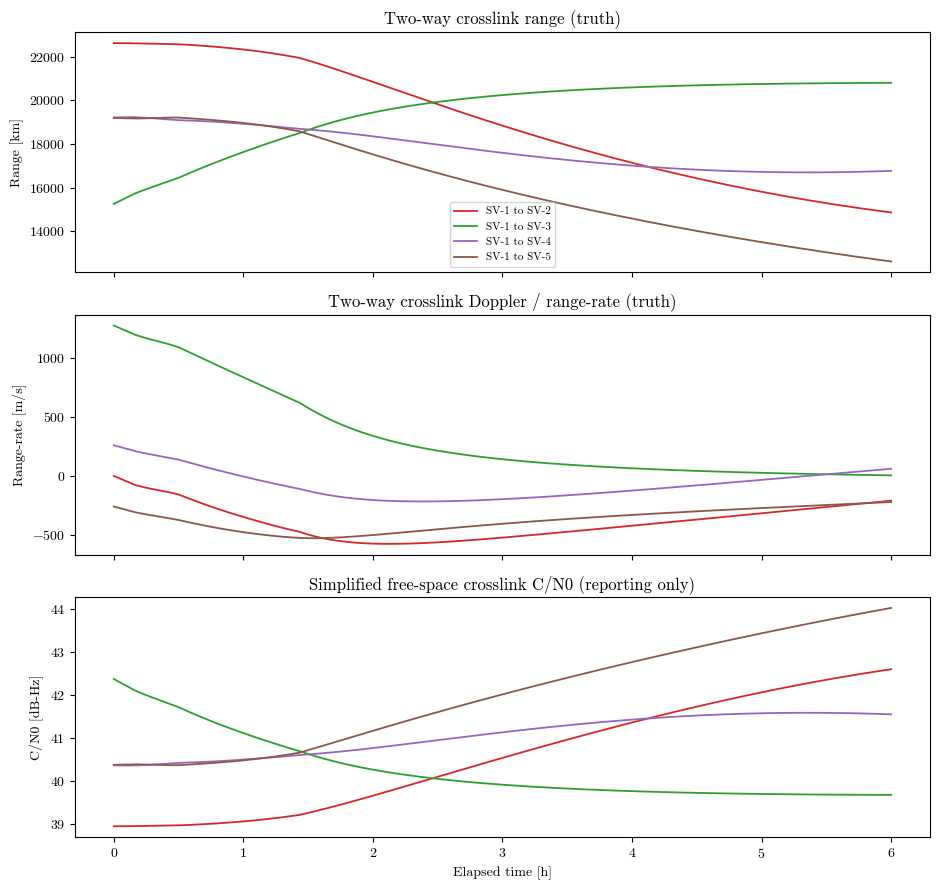

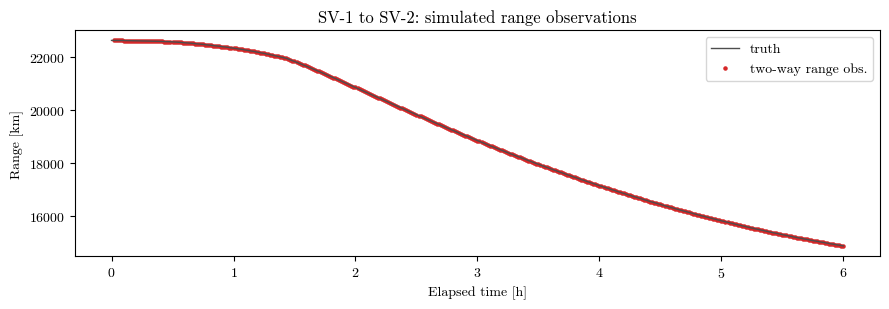

In [6]:
n_links = n_sat - 1
link_names = sat_names[1:]  # SV-1-referenced crosslinks (columns of range_true_m)

fig, axes = plt.subplots(3, 1, figsize=(9.5, 9), sharex=True)

for i in range(n_links):
    color = link_colors[i]
    label = f"{sat_names[0]} to {link_names[i]}"
    axes[0].plot(t_h, res.range_true_m[:, i] / 1e3, color=color, lw=1.3, label=label)
    axes[1].plot(t_h, res.range_rate_true_mps[:, i], color=color, lw=1.3, label=label)
    axes[2].plot(t_h, res.cn0_dbhz[:, i], color=color, lw=1.3, label=label)

axes[0].set_ylabel("Range [km]")
axes[0].set_title("Two-way crosslink range (truth)")
axes[0].legend(loc="best", fontsize=8)

axes[1].set_ylabel("Range-rate [m/s]")
axes[1].set_title("Two-way crosslink Doppler / range-rate (truth)")

axes[2].set_ylabel("C/N0 [dB-Hz]")
axes[2].set_xlabel("Elapsed time [h]")
axes[2].set_title("Simplified free-space crosslink C/N0 (reporting only)")

plt.tight_layout()
plt.show()

# Zoom on one link to show the simulated noisy observations against truth
i_demo = 0
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(t_h, res.range_true_m[:, i_demo] / 1e3, color="0.3", lw=1, label="truth")
ax.scatter(
    t_h,
    res.range_obs_m[:, i_demo] / 1e3,
    s=5,
    color=link_colors[i_demo],
    label="two-way range obs.",
)
ax.set_ylabel("Range [km]")
ax.set_xlabel("Elapsed time [h]")
ax.set_title(f"{sat_names[0]} to {link_names[i_demo]}: simulated range observations")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 5. Distributed ODTS convergence -- all five filters

Each satellite's own filter is compared against the truth and its formal 3-sigma
covariance envelope. The top row shows every satellite's own position and clock-bias
error under the full system. The bottom row isolates the two observability
contributions across the constellation mean:

- **Orbit** comes from the crosslinks *and the inter-agent exchange*. Two-way ranging
  only fixes geometry relative to neighbors whose states are known; sharing each
  filter's converged self-estimate every 10 minutes is what turns coarse neighbor
  priors into tight ones, so the position error collapses (compare *no-exchange*).
- **Timing** comes from the surface station. Two-way crosslinks cancel clock bias to
  first order, so without the station the clocks drift essentially unobserved (compare
  *no-station*); the rotating one-way pseudorange pins them down.

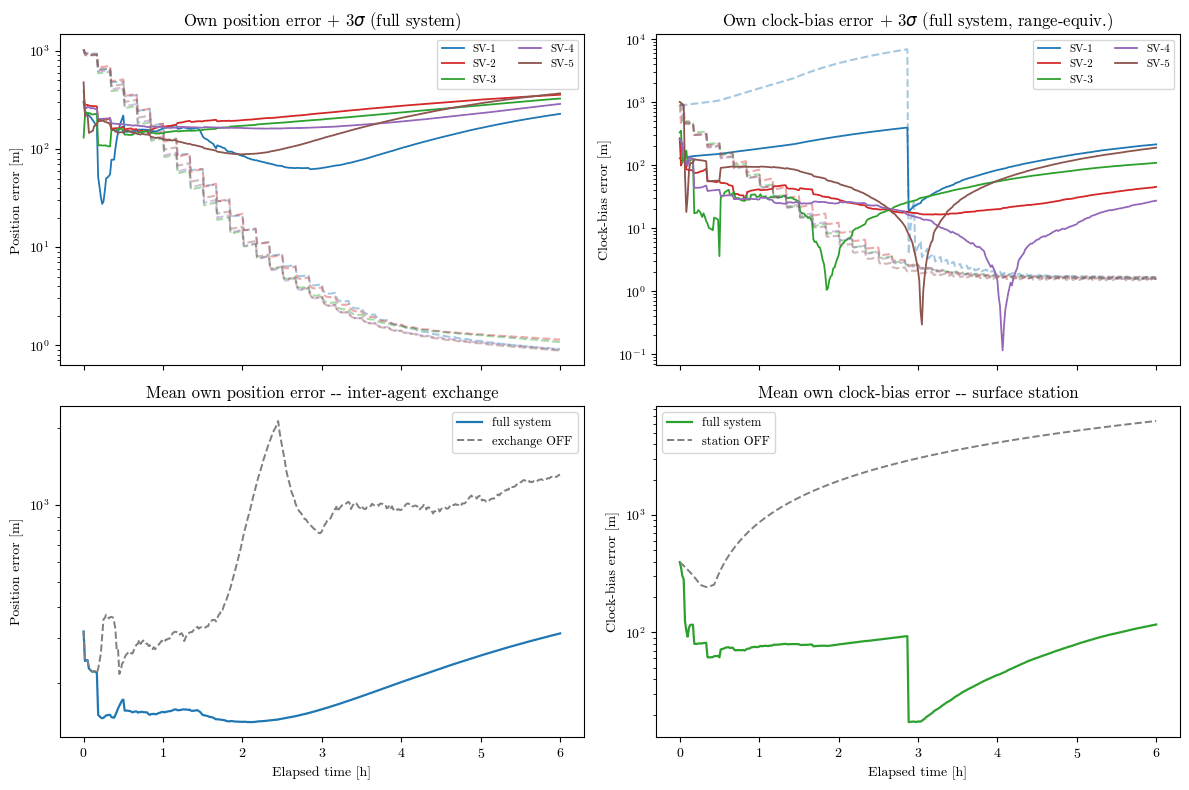

Final constellation-mean own error:
  position : full   313.9 m   |  exchange OFF   1315.7 m
  clock    : full  116.83 m   |  station  OFF  6318.12 m


In [7]:
def pos_err_ts(r, j):
    return np.linalg.norm(r.truth_states[j][:, :3] - own_block(r, j)[:, :3], axis=1)


def pos_3sig(r, j):
    cd, off = r.cov_diag[j], 8 * j
    return 3 * np.sqrt(cd[:, off] + cd[:, off + 1] + cd[:, off + 2])


def clk_err_ts(r, j):
    return np.abs(r.truth_states[j][:, 6] - own_block(r, j)[:, 6]) * C_MPS


def clk_3sig(r, j):
    return 3 * np.sqrt(r.cov_diag[j][:, 8 * j + 6]) * C_MPS


mean_pos = lambda r: np.mean([pos_err_ts(r, j) for j in range(n_sat)], axis=0)
mean_clk = lambda r: np.mean([clk_err_ts(r, j) for j in range(n_sat)], axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# (0,0) per-satellite own position error + 3-sigma (full system)
for j in range(n_sat):
    axes[0, 0].plot(
        t_h, pos_err_ts(res, j), color=sat_colors[j], lw=1.3, label=sat_names[j]
    )
    axes[0, 0].plot(t_h, pos_3sig(res, j), "--", color=sat_colors[j], alpha=0.4)
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Own position error + 3$\\sigma$ (full system)")
axes[0, 0].set_ylabel("Position error [m]")
axes[0, 0].legend(loc="best", fontsize=8, ncol=2)

# (0,1) per-satellite own clock-bias error + 3-sigma (full system)
for j in range(n_sat):
    axes[0, 1].plot(
        t_h, clk_err_ts(res, j), color=sat_colors[j], lw=1.3, label=sat_names[j]
    )
    axes[0, 1].plot(t_h, clk_3sig(res, j), "--", color=sat_colors[j], alpha=0.4)
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Own clock-bias error + 3$\\sigma$ (full system, range-equiv.)")
axes[0, 1].set_ylabel("Clock-bias error [m]")
axes[0, 1].legend(loc="best", fontsize=8, ncol=2)

# (1,0) constellation-mean position: exchange drives the orbit
axes[1, 0].plot(t_h, mean_pos(res), color="#1F77B4", lw=1.6, label="full system")
axes[1, 0].plot(
    t_h, mean_pos(res_noex), color="#7F7F7F", lw=1.4, ls="--", label="exchange OFF"
)
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Mean own position error -- inter-agent exchange")
axes[1, 0].set_ylabel("Position error [m]")
axes[1, 0].set_xlabel("Elapsed time [h]")
axes[1, 0].legend(loc="best", fontsize=9)

# (1,1) constellation-mean clock: station drives the timing
axes[1, 1].plot(t_h, mean_clk(res), color="#2CA02C", lw=1.6, label="full system")
axes[1, 1].plot(
    t_h, mean_clk(res_nost), color="#7F7F7F", lw=1.4, ls="--", label="station OFF"
)
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Mean own clock-bias error -- surface station")
axes[1, 1].set_ylabel("Clock-bias error [m]")
axes[1, 1].set_xlabel("Elapsed time [h]")
axes[1, 1].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

print("Final constellation-mean own error:")
print(
    f"  position : full {mean_pos(res)[-1]:7.1f} m   |  exchange OFF {mean_pos(res_noex)[-1]:8.1f} m"
)
print(
    f"  clock    : full {mean_clk(res)[-1]:7.2f} m   |  station  OFF {mean_clk(res_nost)[-1]:8.2f} m"
)

## 6. Surface-station rotation and pseudorange residuals

The station serves at most one satellite per epoch, cycling round-robin and skipping any
satellite below its elevation mask. The top panel shows which satellite is served over
time; the bottom panel shows the served satellite's pre-fit pseudorange residual, which
should sit within the measurement noise once the filters have converged. A low-perilune
satellite such as `SV-1` drops below the south-pole horizon for long stretches and is
therefore served less often than the others.

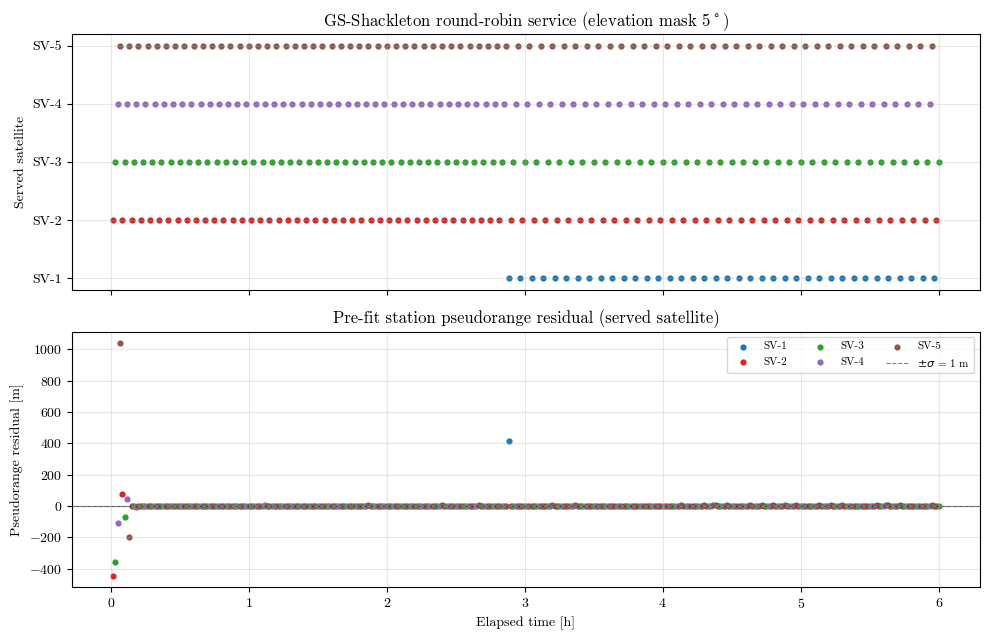

Station served 360 / 360 epochs. Per-satellite: {'SV-1': 38, 'SV-2': 81, 'SV-3': 81, 'SV-4': 80, 'SV-5': 80}
Station pseudorange pre-fit RMS: 67.5 m (measurement noise sigma = 1 m)


In [8]:
served = res.served_sat_idx.astype(int)  # global sat index served (-1 if idle)

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

# Which satellite is served over time (one marker per epoch, colored by satellite).
for j in range(n_sat):
    mask = served == j
    axes[0].scatter(
        t_h[mask], np.full(mask.sum(), j), s=12, color=sat_colors[j], label=sat_names[j]
    )
axes[0].set_yticks(range(n_sat))
axes[0].set_yticklabels(sat_names)
axes[0].set_ylabel("Served satellite")
axes[0].set_title(
    f"{cfg.surface_station.name} round-robin service (elevation mask "
    f"{cfg.surface_station.elevation_mask_deg:.0f}$^\\circ$)"
)
axes[0].grid(True, alpha=0.3)

# Pre-fit station pseudorange residual (NaN where idle -> gaps).
resid = res.station_pr_resid_m
for j in range(n_sat):
    mask = served == j
    axes[1].scatter(
        t_h[mask], resid[mask], s=12, color=sat_colors[j], label=sat_names[j]
    )
axes[1].axhline(0.0, color="k", lw=0.5)
axes[1].axhline(cfg.surface_station.pseudorange_sigma_m, color="0.5", lw=0.8, ls="--")
axes[1].axhline(
    -cfg.surface_station.pseudorange_sigma_m,
    color="0.5",
    lw=0.8,
    ls="--",
    label=f"$\\pm\\sigma$ = {cfg.surface_station.pseudorange_sigma_m:.0f} m",
)
axes[1].set_ylabel("Pseudorange residual [m]")
axes[1].set_xlabel("Elapsed time [h]")
axes[1].set_title("Pre-fit station pseudorange residual (served satellite)")
axes[1].legend(loc="best", fontsize=8, ncol=3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

served_valid = served[served >= 0]
counts = {sat_names[j]: int(np.sum(served_valid == j)) for j in range(n_sat)}
print(
    f"Station served {len(served_valid)} / {len(served) - 1} epochs. Per-satellite: {counts}"
)
rms = np.sqrt(np.nanmean(resid[np.isfinite(resid)] ** 2))
print(
    f"Station pseudorange pre-fit RMS: {rms:.1f} m "
    f"(measurement noise sigma = {cfg.surface_station.pseudorange_sigma_m:.0f} m)"
)

## 7. Consider-state exchange between the parallel filters

Each satellite carries the others as consider states. Between exchanges a consider
block only grows -- it is propagated with process noise and never corrected by that
satellite's own measurements. Every 10 minutes, though, the inter-agent exchange
overwrites it with the neighbor's freshly converged self-estimate (mean **and**
covariance), producing the characteristic **sawtooth**: grow, reset, grow, reset.

Below, one filter's (`SV-1`'s) knowledge of each other satellite is shown. The dashed
line is the same quantity with the exchange disabled: it grows without bound from the
coarse 500 m broadcast prior, which is exactly the neighbor uncertainty that would
otherwise cap the whole constellation's accuracy.

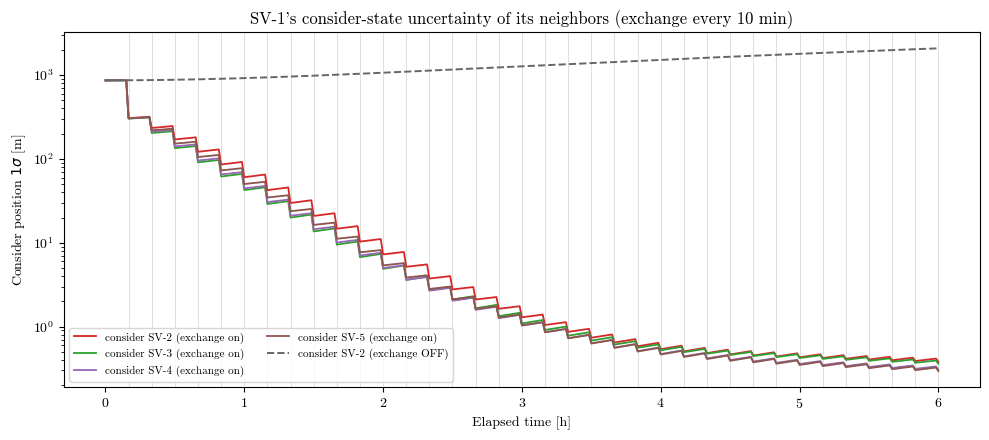

SV-1's consider-SV-2 position 1-sigma at the final epoch: 0.4 m (exchange on) vs 2086.4 m (exchange off)


In [9]:
def consider_pos_sigma(r, filt, g):
    """1-sigma position uncertainty of filter `filt`'s consider block for satellite g."""
    cd, off = r.cov_diag[filt], 8 * g
    return np.sqrt(cd[:, off] + cd[:, off + 1] + cd[:, off + 2])


filt = 0  # inspect SV-1's filter
neighbors = [g for g in range(n_sat) if g != filt]

fig, ax = plt.subplots(figsize=(10, 4.5))
for g in neighbors:
    ax.plot(
        t_h,
        consider_pos_sigma(res, filt, g),
        color=sat_colors[g],
        lw=1.3,
        label=f"consider {sat_names[g]} (exchange on)",
    )
# One neighbor with the exchange disabled, for contrast.
g0 = neighbors[0]
ax.plot(
    t_h,
    consider_pos_sigma(res_noex, filt, g0),
    color="0.4",
    lw=1.4,
    ls="--",
    label=f"consider {sat_names[g0]} (exchange OFF)",
)

# Mark the 10-minute exchange epochs.
for te in np.arange(
    cfg.consider_exchange_interval_s,
    cfg.duration_s + 1,
    cfg.consider_exchange_interval_s,
):
    ax.axvline(te / 3600.0, color="0.85", lw=0.6, zorder=0)

ax.set_yscale("log")
ax.set_ylabel(r"Consider position $1\sigma$ [m]")
ax.set_xlabel("Elapsed time [h]")
ax.set_title(
    f"{sat_names[filt]}'s consider-state uncertainty of its neighbors "
    f"(exchange every {cfg.consider_exchange_interval_s / 60:.0f} min)"
)
ax.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print(
    f"{sat_names[filt]}'s consider-{sat_names[g0]} position 1-sigma at the final epoch: "
    f"{consider_pos_sigma(res, filt, g0)[-1]:.1f} m (exchange on) vs "
    f"{consider_pos_sigma(res_noex, filt, g0)[-1]:.1f} m (exchange off)"
)